Loaded style tokens from: /Users/mloktionov/PycharmProjects/Stellar_Attractor/ANIM/style/hud_style_tokens.py
✅ Saved: ../../Infographics/Telemetry/animations/tables/table_3.mp4


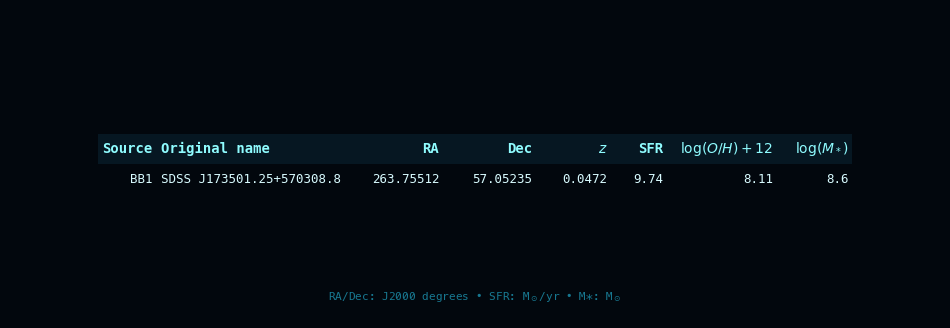

In [4]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter, PillowWriter
import pandas as pd
from pathlib import Path
import importlib.util

# =========================================================
# LOAD STELLAR ATTRACTOR TOKENS
# =========================================================

def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()

    for p in [start, *start.parents]:
        if (p / "style" / "hud_style_tokens.py").exists():
            return p

    raise FileNotFoundError(
        "Не найден style/hud_style_tokens.py ни в текущей папке, ни выше по дереву."
    )


ROOT = find_project_root()
TOKENS_PATH = ROOT / "style" / "hud_style_tokens.py"

spec = importlib.util.spec_from_file_location(
    "hud_style_tokens",
    TOKENS_PATH
)

tokens = importlib.util.module_from_spec(spec)
spec.loader.exec_module(tokens)

def mpl_color(value):
    if isinstance(value, tuple) and len(value) == 3:
        return tuple(v / 255 for v in value)
    return value

print(f"Loaded style tokens from: {TOKENS_PATH}")

# =========================================================
# OUTPUT SETTINGS
# =========================================================

OUTPUT_FORMAT = "mp4"   # "mp4" or "gif"

OUT_DIR = Path("../../Infographics/Telemetry/animations/tables")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_FILE = OUT_DIR / f"table_3.{OUTPUT_FORMAT}"

DURATION_SEC = 18
HOLD_SEC = 5
FPS = 24
N_FRAMES = DURATION_SEC * FPS
HOLD_FRAMES = int(HOLD_SEC * FPS)
REVEAL_FRAMES = max(1, N_FRAMES - HOLD_FRAMES)
DPI = 150

# =========================================================
# STELLAR ATTRACTOR STYLE
# =========================================================

SA_BG = mpl_color(tokens.SA_COLORS_BG)

HEADER_BG = mpl_color(tokens.SA_TABLE_HEADER_BG)
HEADER_TEXT = mpl_color(tokens.SA_TABLE_HEADER_TEXT)

CELL_BG = mpl_color(tokens.SA_TABLE_CELL_BG)
CELL_TEXT = mpl_color(tokens.SA_TABLE_CELL_TEXT)

EDGE_COLOR = mpl_color(tokens.SA_TABLE_EDGE_COLOR)
EDGE_ALPHA = float(tokens.SA_TABLE_EDGE_ALPHA)
EDGE_WIDTH = float(tokens.SA_TABLE_EDGE_WIDTH)

# =========================================================
# MATPLOTLIB STYLE
# =========================================================

plt.rcParams['text.usetex'] = False

plt.rcParams['font.family'] = 'DejaVu Sans Mono'
plt.rcParams['mathtext.fontset'] = 'dejavusans'

plt.rcParams['figure.facecolor'] = SA_BG
plt.rcParams['axes.facecolor'] = SA_BG
plt.rcParams['savefig.facecolor'] = SA_BG

plt.rcParams['text.color'] = CELL_TEXT
plt.rcParams['axes.labelcolor'] = CELL_TEXT
plt.rcParams['xtick.color'] = CELL_TEXT
plt.rcParams['ytick.color'] = CELL_TEXT



# =========================================================
# DATA
# =========================================================

data = {
    "Source": ["BB1", "BB2", "BB3", "BB4", "BB5", "BB6", "BB7", "BB8"],
    "Original name": [
        "SDSS J173501.25+570308.8",
        "SDSS J150934.17+373146.1",
        "SDSS J024052.19-082827.4",
        "SDSS J085115.65+584055.0",
        "SDSS J014653.30+031922.3",
        "SDSS J122611.89+041536.0",
        "SDSS J155624.47+480645.7",
        "SDSS J082540.44+184617.2"
    ],
    r"RA (J2000) [degrees]": [
        263.75512, 227.39239, 40.21748, 132.81521,
        26.72211, 186.54955, 239.10198, 126.41854
    ],
    r"Dec (J2000) [degrees]": [
        57.05235, 37.52948, -8.47430, 58.68195,
        3.32288, 4.26002, 48.11272, 18.77145
    ],
    r"$z$": [
        0.0472, 0.03259, 0.0822, 0.0919,
        0.04672, 0.0942, 0.05024, 0.03792
    ],
    r"SFR [$M_\odot$/yr]": [
        9.74, 1.61, 7.0, 6.4,
        1.16, 5.29, 1.08, 0.50
    ],
    r"$\log(O/H)+12$": [
        8.11, 7.87, 7.91, 7.87,
        7.62, 8.00, 7.83, 7.79
    ],
    r"$\log(M_*)$ [$M_\odot$]": [
        8.6, 8.1, 8.5, 8.7,
        7.7, None, 7.9, 7.2
    ]
}

df = pd.DataFrame(data)

# =========================================================
# SCENE
# =========================================================

fig, ax = plt.subplots(figsize=(12, 4))

fig.patch.set_facecolor(SA_BG)
ax.set_facecolor(SA_BG)
ax.axis('off')

# =========================================================
# ANIMATION
# =========================================================

def animate(i):

    ax.clear()
    ax.set_facecolor(SA_BG)
    ax.axis('off')

    if i < REVEAL_FRAMES:
        rows_to_show = int((i + 1) * len(df) / REVEAL_FRAMES)
        rows_to_show = max(1, min(len(df), rows_to_show))
    else:
        rows_to_show = len(df)
    partial_df = df.iloc[:rows_to_show]

    display_columns = [
        "Source",
        "Original name",
        "RA",
        "Dec",
        r"$z$",
        "SFR",
        r"$\log(O/H)+12$",
        r"$\log(M_*)$",
    ]

    table = ax.table(
        cellText=partial_df.values,
        colLabels=display_columns,
        loc='center',
        cellLoc='right'
    )

    ax.text(
        0.5, 0.06,
        "RA/Dec: J2000 degrees • SFR: M$_\\odot$/yr • M*: M$_\\odot$",
        transform=ax.transAxes,
        ha="center",
        color=EDGE_COLOR,
        fontsize=8,
        alpha=0.55,
        fontfamily="Menlo"
    )

    # -------------------------------------------------
    # TABLE GLOBAL SETTINGS
    # -------------------------------------------------

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.18, 1.82)

    # -------------------------------------------------
    # COLUMN WIDTHS / PADDING
    # -------------------------------------------------

    widths = {
        0: 0.06,   # Source
        1: 0.21,   # Original name

        2: 0.10,   # RA
        3: 0.10,   # Dec

        4: 0.08,   # z
        5: 0.06,   # SFR
        6: 0.12,   # O/H
        7: 0.08,   # log(M*)
    }

    for (row, col), cell in table.get_celld().items():

        if col in widths:
            cell.set_width(widths[col])

        cell.PAD = 0.035

        # дальше стили
        

    for (row, col), cell in table.get_celld().items():

        cell.set_edgecolor(SA_BG)
        cell.set_linewidth(0.0)

        if row == 0:
            cell.set_facecolor(HEADER_BG)
            cell.set_text_props(
                color=HEADER_TEXT,
                weight='bold',
                fontsize=10,
                ha='center',
                fontfamily='DejaVu Sans Mono'
            )

        else:
            cell.set_facecolor(CELL_BG)
            cell.set_text_props(
                color=CELL_TEXT,
                fontsize=9,
                fontfamily='DejaVu Sans Mono'
            )
        
        if col == 1:
            ha = 'left'
            fs=6
        else:
            ha = 'right'
            fs=5
        
        cell.set_text_props(ha=ha)

# =========================================================
# CREATE ANIMATION
# =========================================================

ani = animation.FuncAnimation(
    fig,
    animate,
    frames=N_FRAMES,
    interval=1000 / FPS,
    blit=False
)

# =========================================================
# SAVE
# =========================================================

if OUTPUT_FORMAT.lower() == "mp4":

    writer = FFMpegWriter(
        fps=FPS,
        metadata=dict(artist='Stellar Attractor'),
        bitrate=1800
    )

    ani.save(
        OUT_FILE,
        writer=writer,
        dpi=DPI
    )

elif OUTPUT_FORMAT.lower() == "gif":

    writer = PillowWriter(fps=FPS)

    ani.save(
        OUT_FILE,
        writer=writer,
        dpi=DPI
    )

else:
    raise ValueError("OUTPUT_FORMAT must be 'mp4' or 'gif'")

print(f"✅ Saved: {OUT_FILE}")